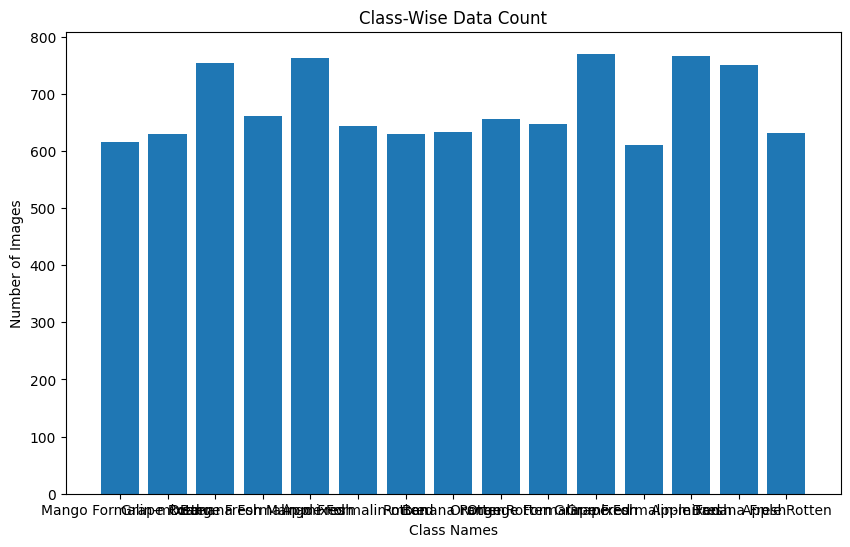

Found 8127 images belonging to 15 classes.
Found 2027 images belonging to 15 classes.


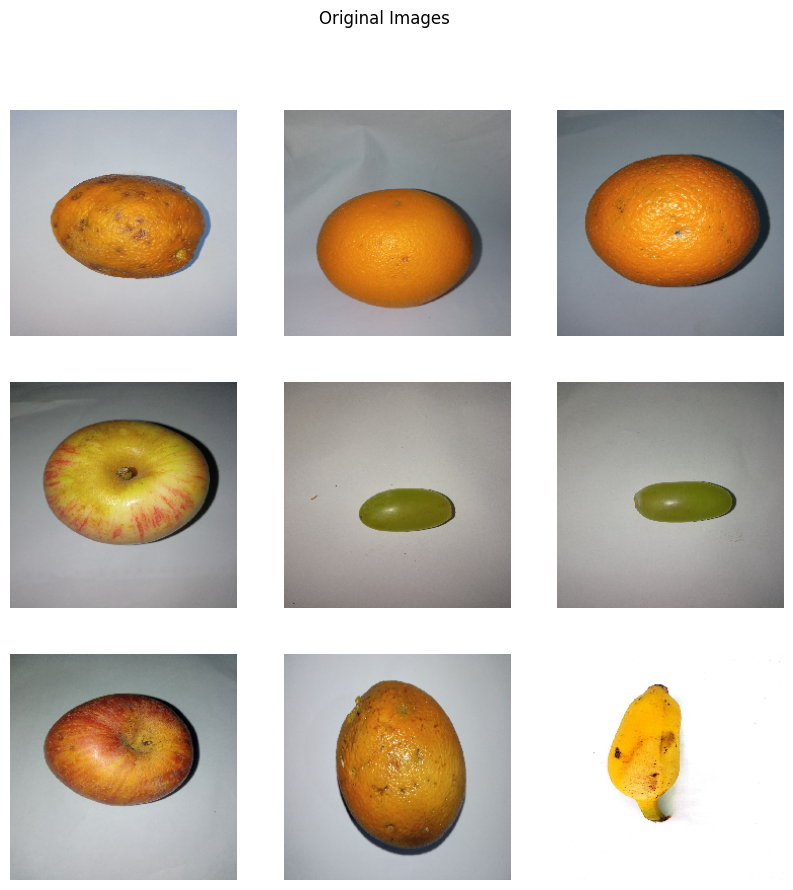

Found 10154 images belonging to 15 classes.


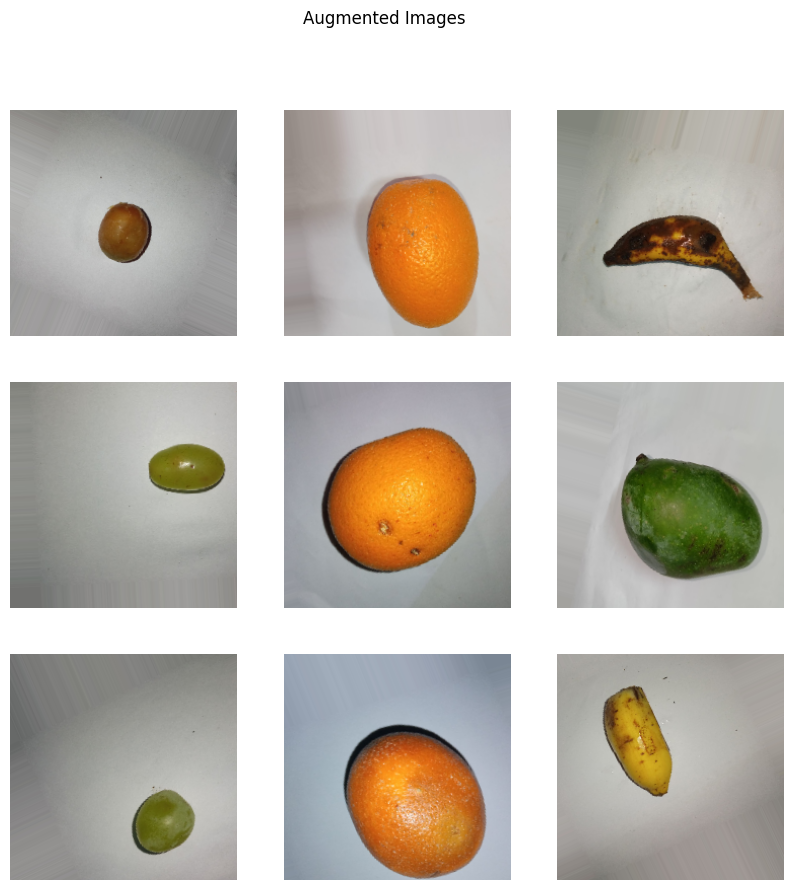

Training fold 1...
Epoch 1/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 29s 83ms/step - accuracy: 0.6280 - loss: 1.4345 - val_accuracy: 0.8795 - val_loss: 0.3044
Epoch 2/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8695 - loss: 0.3560 - val_accuracy: 0.8475 - val_loss: 0.3561
Epoch 3/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8865 - loss: 0.2792 - val_accuracy: 0.8973 - val_loss: 0.2540
Epoch 4/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.9189 - loss: 0.2140 - val_accuracy: 0.9121 - val_loss: 0.2468
Epoch 5/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9358 - loss: 0.1710 - val_accuracy: 0.9188 - val_loss: 0.2213
Epoch 6/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9417 - loss: 0.1447 - val_accuracy: 0.9102 - val_loss: 0.2580
Epoch 7/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9473 - loss: 0.1339 - val_accuracy: 0.9274 - val_loss: 0.1992
Epoch 8/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9624 - los

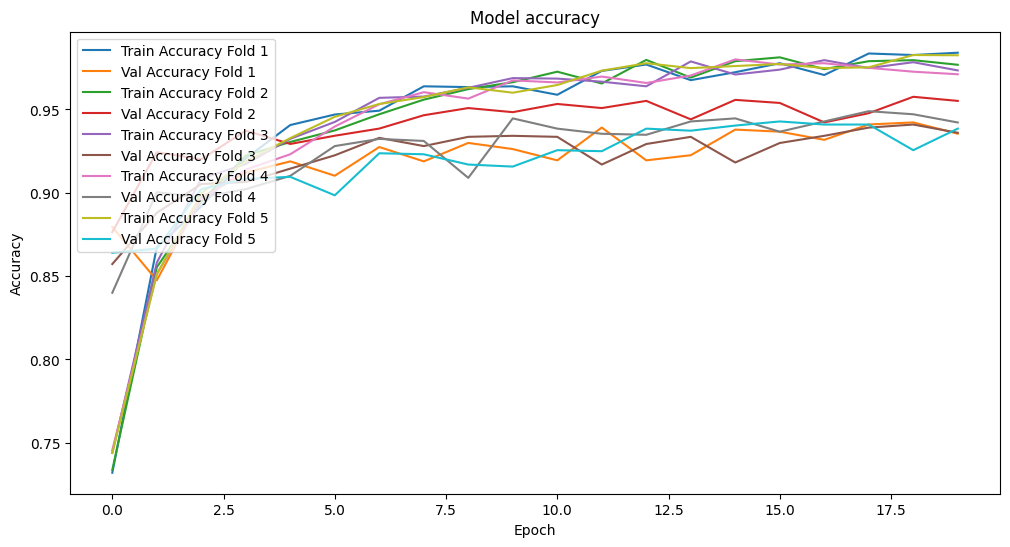

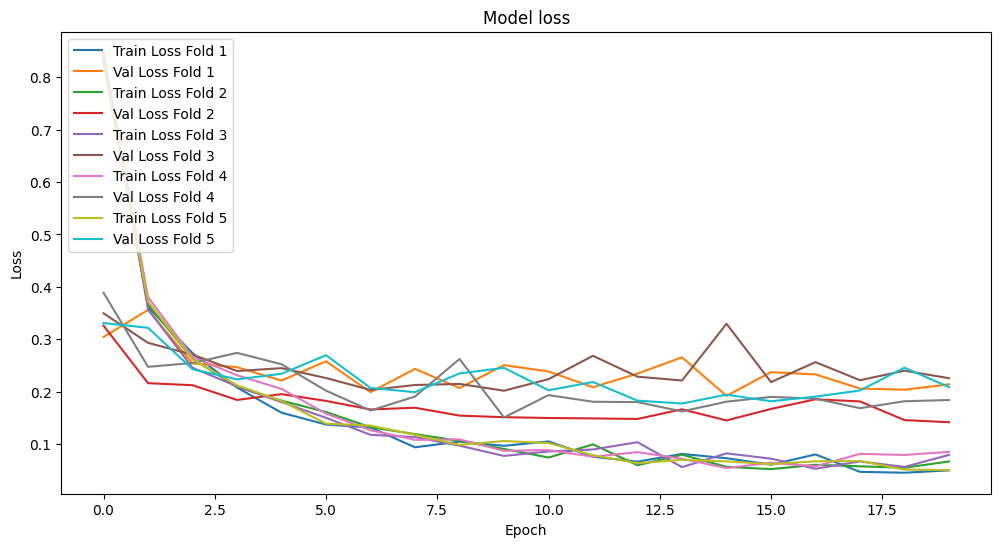

Average Validation Accuracy: 0.9414288520812988
Validation Accuracies for each fold: [0.9354243278503418, 0.9551045298576355, 0.9359999895095825, 0.9421538710594177, 0.9384615421295166]
Average TPR: [0.88915029 0.9062066  0.95070212 0.8809925  0.92079068 0.97770145
 0.96557137 0.94670217 0.90788819 0.98499934 0.98067087 0.93635756
 0.9223772  0.99351675 0.96574933]
Average TNR: [0.99316791 0.99254788 0.99671871 0.99342921 0.9906956  0.99960396
 0.99712745 0.99201839 0.99829354 0.99790664 0.99867023 0.9936809
 0.99561399 0.99907801 0.99855545]
Average FPR: [0.00683209 0.00745212 0.00328129 0.00657079 0.0093044  0.00039604
 0.00287255 0.00798161 0.00170646 0.00209336 0.00132977 0.0063191
 0.00438601 0.00092199 0.00144455]
Average FNR: [0.11084971 0.0937934  0.04929788 0.1190075  0.07920932 0.02229855
 0.03442863 0.05329783 0.09211181 0.01500066 0.01932913 0.06364244
 0.0776228  0.00648325 0.03425067]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Concatenate, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
import os

dataset_dir = '/kaggle/input/fruite-dataset/Fruits Data'

class_counts = {}
for subdir, dirs, files in os.walk(dataset_dir):
    for dir in dirs:
        class_counts[dir] = len(os.listdir(os.path.join(subdir, dir)))

plt.figure(figsize=(30, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.title('Class-Wise Data Count')
plt.xlabel('Class Names')
plt.ylabel('Number of Images')
plt.show()

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    subset='validation'
)

augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

def plot_images(generator, title):
    sample_images, _ = next(generator)
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(sample_images[i])
        plt.axis('off')
    plt.suptitle(title)
    plt.show()
plot_images(train_generator, "Original Images")
plot_images(augmented_datagen.flow_from_directory(dataset_dir, target_size=(224, 224), batch_size=32, class_mode='sparse', subset='training'), "Augmented Images")


def create_hybrid_model(input_shape=(224, 224, 3), num_classes=len(class_counts)):
    input_tensor = Input(shape=input_shape)

    mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=input_tensor)
    for layer in mobilenet_base.layers:
        layer.trainable = False
    mobilenet_features = Flatten()(mobilenet_base.output)
    mobilenet_features = Dense(256, activation='relu')(mobilenet_features)
    mobilenet_features = BatchNormalization()(mobilenet_features)
    mobilenet_features = Dropout(0.5)(mobilenet_features)

    mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=input_tensor)
    for layer in mobilenet_base.layers:
        layer.trainable = False
    mobilenet_features = Flatten()(mobilenet_base.output)
    mobilenet_features = Dense(256, activation='relu')(mobilenet_features)
    mobilenet_features = BatchNormalization()(mobilenet_features)
    mobilenet_features = Dropout(0.5)(mobilenet_features)

    combined_features = Concatenate()([mobilenet_features, mobilenet_features])
    x = Dense(512, activation='relu')(combined_features)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output)
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model

def generator_to_numpy(generator):
    images = []
    labels = []
    for _ in range(len(generator)):
        img, lbl = next(generator)
        images.append(img)
        labels.append(lbl)
    return np.concatenate(images), np.concatenate(labels)

X, y = generator_to_numpy(train_generator)

def calculate_metrics(conf_matrix):
    FP = conf_matrix.sum(axis=0) - np.diag(conf_matrix)  
    FN = conf_matrix.sum(axis=1) - np.diag(conf_matrix)
    TP = np.diag(conf_matrix)
    TN = conf_matrix.sum() - (FP + FN + TP)

    TPR = TP / (TP + FN)
    TNR = TN / (TN + FP)
    FPR = FP / (FP + TN)
    FNR = FN / (FN + TP)

    return TPR, TNR, FPR, FNR

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
accuracies = []
histories = []
tpr_list = []
tnr_list = []
fpr_list = []
fnr_list = []
for train_index, val_index in kf.split(X):
    print(f"Training fold {fold_no}...")
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]
    model = create_hybrid_model()
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))
    histories.append(history)
    y_val_pred = model.predict(X_val)
    y_val_pred_classes = np.argmax(y_val_pred, axis=1)
    conf_matrix = confusion_matrix(y_val, y_val_pred_classes)
    class_report = classification_report(y_val, y_val_pred_classes, target_names=list(class_counts.keys()))
    TPR, TNR, FPR, FNR = calculate_metrics(conf_matrix)
    tpr_list.append(TPR)
    tnr_list.append(TNR)
    fpr_list.append(FPR)
    fnr_list.append(FNR)
    print(f"Fold {fold_no} - Classification Report:\n{class_report}")
    print(f"Fold {fold_no} - Confusion Matrix:\n{conf_matrix}")
    print(f"Fold {fold_no} - TPR: {TPR}")
    print(f"Fold {fold_no} - TNR: {TNR}")
    print(f"Fold {fold_no} - FPR: {FPR}")
    print(f"Fold {fold_no} - FNR: {FNR}")
    accuracies.append(history.history['val_accuracy'][-1])
    fold_no += 1

plt.figure(figsize=(12, 6))
for i, history in enumerate(histories):
    plt.plot(history.history['accuracy'], label=f'Train Accuracy Fold {i+1}')
    plt.plot(history.history['val_accuracy'], label=f'Val Accuracy Fold {i+1}')
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

plt.figure(figsize=(12, 6))
for i, history in enumerate(histories):
    plt.plot(history.history['loss'], label=f'Train Loss Fold {i+1}')
    plt.plot(history.history['val_loss'], label=f'Val Loss Fold {i+1}')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

print(f"Average Validation Accuracy: {np.mean(accuracies)}")
print(f"Validation Accuracies for each fold: {accuracies}")

avg_tpr = np.mean(tpr_list, axis=0)
avg_tnr = np.mean(tnr_list, axis=0)
avg_fpr = np.mean(fpr_list, axis=0)
avg_fnr = np.mean(fnr_list, axis=0)

print(f"Average TPR: {avg_tpr}")
print(f"Average TNR: {avg_tnr}")
print(f"Average FPR: {avg_fpr}")
print(f"Average FNR: {avg_fnr}")
